In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/content_data/content_data/000000000016.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/content_data/content_data/000000000001.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/content_data/content_data/000000000108.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/style_data/style_data/30.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/style_data/style_data/31.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/style_data/style_data/32.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/adain-pre/decoder_final.pth
/kaggle/input/datasets/shanmukhmaruthireddy/adain-pre/vgg_normalised.pth


In [2]:
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [3]:
import torch.nn as nn
import torch

class VGGEncoder(nn.Module):
    def __init__(self, vgg_path):
        super(VGGEncoder, self).__init__()

        self.vgg = nn.Sequential(
            nn.Conv2d(3, 3, (1, 1)),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(3, 64, (3, 3)),
            nn.ReLU(),  # relu1-1
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(64, 64, (3, 3)),
            nn.ReLU(),  # relu1-2
            nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(64, 128, (3, 3)),
            nn.ReLU(),  # relu2-1
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(128, 128, (3, 3)),
            nn.ReLU(),  # relu2-2
            nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(128, 256, (3, 3)),
            nn.ReLU(),  # relu3-1
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(256, 256, (3, 3)),
            nn.ReLU(),  # relu3-2
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(256, 256, (3, 3)),
            nn.ReLU(),  # relu3-3
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(256, 256, (3, 3)),
            nn.ReLU(),  # relu3-4
            nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(256, 512, (3, 3)),
            nn.ReLU(),  # relu4-1, this is the last layer used
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(512, 512, (3, 3)),
            nn.ReLU(),  # relu4-2
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(512, 512, (3, 3)),
            nn.ReLU(),  # relu4-3
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(512, 512, (3, 3)),
            nn.ReLU(),  # relu4-4
            nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(512, 512, (3, 3)),
            nn.ReLU(),  # relu5-1
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(512, 512, (3, 3)),
            nn.ReLU(),  # relu5-2
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(512, 512, (3, 3)),
            nn.ReLU(),  # relu5-3
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(512, 512, (3, 3)),
            nn.ReLU()  # relu5-4
        )
        self.vgg.load_state_dict(torch.load(vgg_path))
        self.vgg = nn.Sequential(*list(self.vgg.children())[:31])
        enc_layers = list(self.vgg.children())
        self.enc_1 = nn.Sequential(*enc_layers[:4])
        self.enc_2 = nn.Sequential(*enc_layers[4:11])
        self.enc_3 = nn.Sequential(*enc_layers[11:18])
        self.enc_4 = nn.Sequential(*enc_layers[18:31])

        for name in ['enc_1', 'enc_2', 'enc_3', 'enc_4']:
            for param in getattr(self, name).parameters():
                param.requires_grad = False

    def forward(self, input, is_test=False):
        h1 = self.enc_1(input)
        h2 = self.enc_2(h1)
        h3 = self.enc_3(h2)
        h4 = self.enc_4(h3)
        if is_test:
            return h4
        return h1, h2, h3, h4


class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(512, 256, (3, 3)),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(256, 256, (3, 3)),
            nn.ReLU(),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(256, 256, (3, 3)),
            nn.ReLU(),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(256, 256, (3, 3)),
            nn.ReLU(),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(256, 128, (3, 3)),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(128, 128, (3, 3)),
            nn.ReLU(),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(128, 64, (3, 3)),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(64, 64, (3, 3)),
            nn.ReLU(),
            nn.ReflectionPad2d((1, 1, 1, 1)),
            nn.Conv2d(64, 3, (3, 3)),         
        )

    def forward(self, input):
        return self.net(input)

In [4]:
def calc_mean_std(feat, eps=1e-5):
    # feat shape: [batch, channels, height, width]
    size = feat.size()
    assert len(size) == 4

    batch_size, channels = size[:2]

    feat_mean = feat.view(batch_size, channels, -1).mean(dim=2)
    feat_mean = feat_mean.view(batch_size, channels, 1, 1)

    feat_var = feat.view(batch_size, channels, -1).var(
        dim=2, unbiased=False
    ) + eps

    feat_std = feat_var.sqrt().view(batch_size, channels, 1, 1)

    return feat_mean, feat_std


def adaptive_instance_normalization(content_feat, style_feat):
    size = content_feat.size()

    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)

    normalized_content = (
        content_feat - content_mean.expand(size)
    ) / content_std.expand(size)

    return normalized_content * style_std.expand(size) + style_mean.expand(size)

In [5]:
# Paths to your uploaded files

VGG_PATH = "/kaggle/input/datasets/shanmukhmaruthireddy/adain-pre/vgg_normalised.pth"

DECODER_PATH = "/kaggle/input/datasets/shanmukhmaruthireddy/adain-pre/decoder_final.pth"

# Load encoder and decoder

encoder = VGGEncoder(VGG_PATH).to(device)
decoder = Decoder().to(device)

decoder.load_state_dict(torch.load(DECODER_PATH, map_location=device))

# Set to evaluation mode

encoder.eval()
decoder.eval()

print("VGG Encoder Loaded Successfully")
print("Trained AdaIN Decoder Loaded Successfully")

VGG Encoder Loaded Successfully
Trained AdaIN Decoder Loaded Successfully


In [6]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/content_data/content_data/000000000016.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/content_data/content_data/000000000001.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/content_data/content_data/000000000108.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/style_data/style_data/30.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/style_data/style_data/31.jpg
/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/style_data/style_data/32.jpg


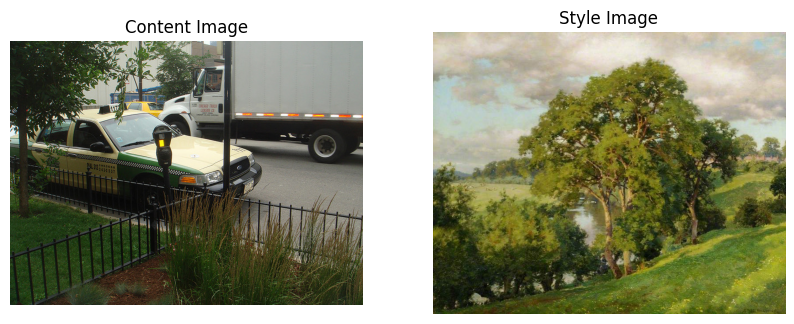

In [7]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# Image paths
CONTENT_PATH = "/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/content_data/content_data/000000000001.jpg"

STYLE_PATH = "/kaggle/input/datasets/shanmukhmaruthireddy/nstdata/style_data/style_data/30.jpg"


# Load images
content_image = Image.open(CONTENT_PATH).convert("RGB")
style_image = Image.open(STYLE_PATH).convert("RGB")


# Display images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(content_image)
plt.title("Content Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_image)
plt.title("Style Image")
plt.axis("off")

plt.show()

Content Tensor Shape: torch.Size([1, 3, 512, 512])
Style Tensor Shape: torch.Size([1, 3, 512, 512])


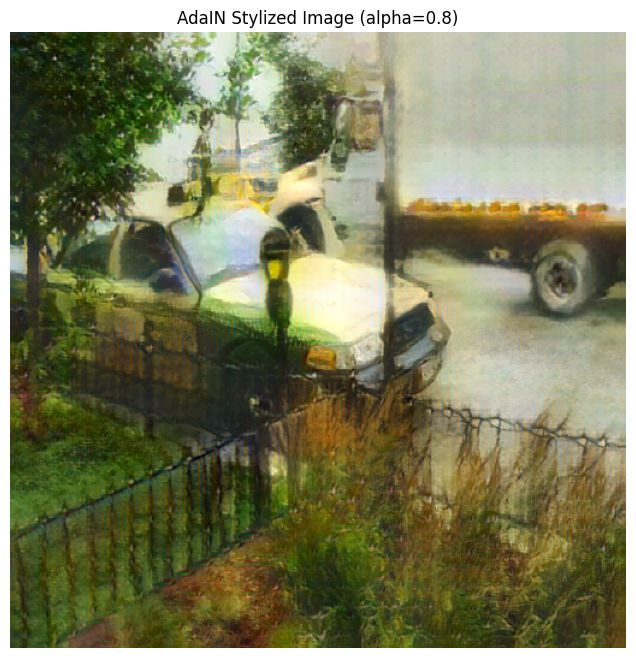

In [8]:
from torchvision import transforms
import torch
import matplotlib.pyplot as plt

# -----------------------------
# Image preprocessing
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

# Convert images to tensors
content_tensor = transform(content_image).unsqueeze(0).to(device)
style_tensor = transform(style_image).unsqueeze(0).to(device)

print("Content Tensor Shape:", content_tensor.shape)
print("Style Tensor Shape:", style_tensor.shape)


# -----------------------------
# AdaIN Style Transfer
# -----------------------------
alpha = 0.8   # 0 = original image, 1 = full style

with torch.no_grad():

    # Extract VGG features
    content_features = encoder(content_tensor, is_test=True)
    style_features = encoder(style_tensor, is_test=True)

    # Apply Adaptive Instance Normalization
    target_features = adaptive_instance_normalization(
        content_features,
        style_features
    )

    # Control style intensity
    target_features = (
        alpha * target_features +
        (1 - alpha) * content_features
    )

    # Decode features into image
    generated_image = decoder(target_features)


# -----------------------------
# Post-processing
# -----------------------------
output = generated_image.squeeze(0).cpu()

# Keep pixel values between 0 and 1
output = output.clamp(0, 1)

# Change from C x H x W to H x W x C
output = output.permute(1, 2, 0)


# -----------------------------
# Display Result
# -----------------------------
plt.figure(figsize=(8, 8))
plt.imshow(output)
plt.title(f"AdaIN Stylized Image (alpha={alpha})")
plt.axis("off")
plt.show()

In [9]:
!pip install gradio -q


In [10]:
import gradio as gr
from PIL import Image
import numpy as np

In [11]:
def stylize(content_image, style_image, alpha):
    
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor()
    ])

    # Convert PIL images to tensors
    content_tensor = transform(content_image).unsqueeze(0).to(device)
    style_tensor = transform(style_image).unsqueeze(0).to(device)

    with torch.no_grad():

        # Extract features
        content_features = encoder(content_tensor, is_test=True)
        style_features = encoder(style_tensor, is_test=True)

        # AdaIN
        target_features = adaptive_instance_normalization(
            content_features,
            style_features
        )

        # Style strength control
        target_features = (
            alpha * target_features +
            (1 - alpha) * content_features
        )

        # Generate output
        output = decoder(target_features)

    # Convert tensor to image
    output = output.squeeze(0).cpu()
    output = output.clamp(0, 1)
    output = output.permute(1, 2, 0)
    output = (output.numpy() * 255).astype(np.uint8)

    return Image.fromarray(output)

In [16]:
import gradio as gr

# =======================
# NeuralArt Custom CSS
# =======================

css = """
.gradio-container {
    background: linear-gradient(135deg, #020617, #0f172a);
    color: white;
    font-family: Arial, sans-serif;
}

/* Hero Title */
.hero-title {
    text-align: center;
    font-size: 55px;
    font-weight: bold;
    color: #c084fc;
    text-shadow: 0 0 25px #9333ea;
    margin-bottom: 10px;
}

/* Subtitle */
.hero-subtitle {
    text-align: center;
    font-size: 20px;
    color: #e879f9;
    margin-bottom: 5px;
}

/* Description */
.hero-description {
    text-align: center;
    color: #d8b4fe;
    font-size: 16px;
    margin-bottom: 20px;
}

/* Gradient divider */
.divider {
    height: 3px;
    width: 200px;
    margin: 20px auto;
    background: linear-gradient(90deg, #7c3aed, #ec4899);
    border-radius: 10px;
}


/* Cards */
.gradio-container .block {
    background: rgba(255,255,255,0.06);
    border: 1px solid rgba(192,132,252,0.4);
    border-radius: 18px;
}


/* Slider */
input[type="range"] {
    accent-color: #8b5cf6;
}


/* Generate Button */
button.primary {
    background: linear-gradient(90deg, #7c3aed, #ec4899) !important;
    color: white !important;
    font-size: 22px !important;
    font-weight: bold !important;
    border-radius: 30px !important;
    height: 60px !important;
    border: none !important;
}


button.primary:hover {
    box-shadow: 0 0 25px #c084fc;
    transform: scale(1.02);
    transition: 0.3s;
}


/* Hide Gradio Footer */
footer {
    display: none !important;
}
"""


# =======================
# Gradio Application
# =======================

with gr.Blocks(
    css=css,
    title="NeuralArt AI - AdaIN Style Transfer",
    theme=gr.themes.Soft()
) as demo:

    # Hero Section
    gr.HTML("""
        <div class="hero-title">
            🎨 NeuralArt AI
        </div>

        <div class="hero-subtitle">
            Transform Photos into Artistic Masterpieces
        </div>

        <div class="hero-description">
            Powered by Adaptive Instance Normalization (AdaIN) and Deep Neural Networks
        </div>

        <div class="divider"></div>
    """)


    # Image Inputs
    with gr.Row():

        content_input = gr.Image(
            type="pil",
            label="📷 Content Image"
        )

        style_input = gr.Image(
            type="pil",
            label="🎨 Style Image"
        )


    # Style Strength
    strength = gr.Slider(
        minimum=0,
        maximum=1,
        value=0.8,
        step=0.1,
        label="✨ Style Strength"
    )


    # Generate Button
    generate_btn = gr.Button(
        "🚀 Generate Artwork",
        variant="primary"
    )


    # Output
    output = gr.Image(
        type="pil",
        label="🖼️ Generated Artwork"
    )


    # Connect Model
    generate_btn.click(
        fn=stylize,
        inputs=[
            content_input,
            style_input,
            strength
        ],
        outputs=output
    )


# Launch App
demo.launch(debug=True)

/tmp/ipykernel_59/455600515.py:94: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_59/455600515.py:94: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://3302722f70c1b9597e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://3302722f70c1b9597e.gradio.live
